In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import scanpy as sc
import seaborn as sns

import os
main_path = os.getcwd()

import sys
sys.path.append(main_path)

from analysis.libraries.data_processing import match_core_to_ACA

In [2]:
import matplotlib as mpl
mpl.rcParams["pdf.use14corefonts"] = True
mpl.rcParams['pdf.fonttype'] = 42
sns.set_context("paper", font_scale=3.0)

In [6]:
adata = ad.read_h5ad(os.path.join(main_path, 'data/LATTICeA_hallmarks_adata_ssl_leiden_224px_fold0.h5ad'))

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [7]:
sc.pp.log1p(adata, base=10)
sc.pp.combat(adata, key='TMA')

In [8]:
cores_df = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'))
    
hallmarks_cores = adata.obs['Core_ID'].unique()
hallmarks_core_dict = dict()

for core in hallmarks_cores:
    hallmarks_core_dict[core] = match_core_to_ACA(core, cores_df)

In [9]:
adata = adata[~adata.obs['leiden'].isna()]

adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,t_CellX,t_CellY,y_start,y_stop,x_start,x_stop,leiden
2,17542.868552,-45460.892577,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,442.497352,-111.521377,111.3728,222.7456,334.1184,445.4912,6
4,17469.690327,-45463.795477,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,369.319127,-114.424277,111.3728,222.7456,334.1184,445.4912,6
5,17520.600596,-45461.630647,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,420.229396,-112.259447,111.3728,222.7456,334.1184,445.4912,6
6,17485.202025,-45465.372685,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,384.830825,-116.001485,111.3728,222.7456,334.1184,445.4912,6
7,17524.186586,-45469.499116,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,423.815386,-120.127916,111.3728,222.7456,334.1184,445.4912,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15321376,10108.344216,-48179.921605,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,989.973016,-979.550405,890.9824,1002.3552,890.9824,1002.3552,1
15321378,10033.132785,-48187.297909,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,914.761585,-986.926709,890.9824,1002.3552,890.9824,1002.3552,1
15321379,10080.320795,-48189.404560,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,961.949595,-989.033360,890.9824,1002.3552,890.9824,1002.3552,1
15321382,10084.568030,-48195.721299,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,966.196830,-995.350099,890.9824,1002.3552,890.9824,1002.3552,1


In [10]:
adata.obs['tile'] = adata.obs.apply(lambda row: "_".join([str(row['y_start']), str(row['y_stop']), str(row['x_start']), str(row['x_stop'])]), axis=1)

/tmp/ipykernel_3747137/119622638.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['tile'] = adata.obs.apply(lambda row: "_".join([str(row['y_start']), str(row['y_stop']), str(row['x_start']), str(row['x_stop'])]), axis=1)


In [11]:
adata.obs['samples'] = adata.obs['Core_ID'].map(hallmarks_core_dict)
adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,t_CellX,t_CellY,y_start,y_stop,x_start,x_stop,leiden,tile,samples
2,17542.868552,-45460.892577,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,442.497352,-111.521377,111.3728,222.7456,334.1184,445.4912,6,111.3728_222.7456_334.1184_445.4912,ACA_0553
4,17469.690327,-45463.795477,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,369.319127,-114.424277,111.3728,222.7456,334.1184,445.4912,6,111.3728_222.7456_334.1184_445.4912,ACA_0553
5,17520.600596,-45461.630647,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,420.229396,-112.259447,111.3728,222.7456,334.1184,445.4912,6,111.3728_222.7456_334.1184_445.4912,ACA_0553
6,17485.202025,-45465.372685,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,384.830825,-116.001485,111.3728,222.7456,334.1184,445.4912,6,111.3728_222.7456_334.1184_445.4912,ACA_0553
7,17524.186586,-45469.499116,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,423.815386,-120.127916,111.3728,222.7456,334.1184,445.4912,6,111.3728_222.7456_334.1184_445.4912,ACA_0553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15321376,10108.344216,-48179.921605,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,989.973016,-979.550405,890.9824,1002.3552,890.9824,1002.3552,1,890.9824_1002.3552_890.9824_1002.3552,ACA_1059
15321378,10033.132785,-48187.297909,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,914.761585,-986.926709,890.9824,1002.3552,890.9824,1002.3552,1,890.9824_1002.3552_890.9824_1002.3552,ACA_1059
15321379,10080.320795,-48189.404560,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,961.949595,-989.033360,890.9824,1002.3552,890.9824,1002.3552,1,890.9824_1002.3552_890.9824_1002.3552,ACA_1059
15321382,10084.568030,-48195.721299,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,966.196830,-995.350099,890.9824,1002.3552,890.9824,1002.3552,1,890.9824_1002.3552_890.9824_1002.3552,ACA_1059


### Cell composition

In [12]:
frequencies_list = []

grouped = adata.obs.groupby(['leiden', 'Core_ID', 'tile'])

for (cluster, core, tile), tile_df in grouped:
    num_cells = tile_df.shape[0]
    cell_frequencies = tile_df['Region'].value_counts().to_frame().T 
    cell_frequencies['core'] = core
    cell_frequencies['tile'] = tile
    cell_frequencies['leiden'] = cluster
    frequencies_list.append(cell_frequencies)

In [13]:
cluster_cell_frequencies = pd.concat(frequencies_list).reset_index()
cluster_cell_frequencies

,index,Stroma,Tumour,Necrosis,core,tile,leiden
0,Region,52,2,0,01-02-B,111.3728_222.7456_779.6096_890.9824,0
1,Region,14,5,0,01-02-B,111.3728_222.7456_890.9824_1002.3552,0
2,Region,27,13,0,01-02-B,222.7456_334.1184_445.4912_556.864,0
3,Region,19,27,0,01-02-B,222.7456_334.1184_668.2368_779.6096,0
4,Region,33,18,0,01-02-B,222.7456_334.1184_779.6096_890.9824,0
...,...,...,...,...,...,...,...
172335,Region,87,0,0,23-13-F,779.6096_890.9824_334.1184_445.4912,24
172336,Region,86,0,0,23-13-F,779.6096_890.9824_445.4912_556.864,24
172337,Region,79,11,0,23-13-F,779.6096_890.9824_668.2368_779.6096,24
172338,Region,77,1,0,23-14-I,222.7456_334.1184_222.7456_334.1184,24


In [14]:
cluster_cell_frequencies['total_cells'] = cluster_cell_frequencies.apply(lambda row: np.sum([row['Tumour'], row['Stroma'], row['Necrosis']]), axis=1)
cluster_cell_frequencies['prop_tumour'] = cluster_cell_frequencies['Tumour'] / cluster_cell_frequencies['total_cells']
cluster_cell_frequencies['prop_stroma'] = cluster_cell_frequencies['Stroma'] / cluster_cell_frequencies['total_cells']
cluster_cell_frequencies['prop_necrosis'] = cluster_cell_frequencies['Necrosis'] / cluster_cell_frequencies['total_cells']
cluster_cell_frequencies

,index,Stroma,Tumour,Necrosis,core,tile,leiden,total_cells,prop_tumour,prop_stroma,prop_necrosis
0,Region,52,2,0,01-02-B,111.3728_222.7456_779.6096_890.9824,0,54,0.037037,0.962963,0.0
1,Region,14,5,0,01-02-B,111.3728_222.7456_890.9824_1002.3552,0,19,0.263158,0.736842,0.0
2,Region,27,13,0,01-02-B,222.7456_334.1184_445.4912_556.864,0,40,0.325000,0.675000,0.0
3,Region,19,27,0,01-02-B,222.7456_334.1184_668.2368_779.6096,0,46,0.586957,0.413043,0.0
4,Region,33,18,0,01-02-B,222.7456_334.1184_779.6096_890.9824,0,51,0.352941,0.647059,0.0
...,...,...,...,...,...,...,...,...,...,...,...
172335,Region,87,0,0,23-13-F,779.6096_890.9824_334.1184_445.4912,24,87,0.000000,1.000000,0.0
172336,Region,86,0,0,23-13-F,779.6096_890.9824_445.4912_556.864,24,86,0.000000,1.000000,0.0
172337,Region,79,11,0,23-13-F,779.6096_890.9824_668.2368_779.6096,24,90,0.122222,0.877778,0.0
172338,Region,77,1,0,23-14-I,222.7456_334.1184_222.7456_334.1184,24,78,0.012821,0.987179,0.0


<Axes: xlabel='leiden', ylabel='Necrosis'>

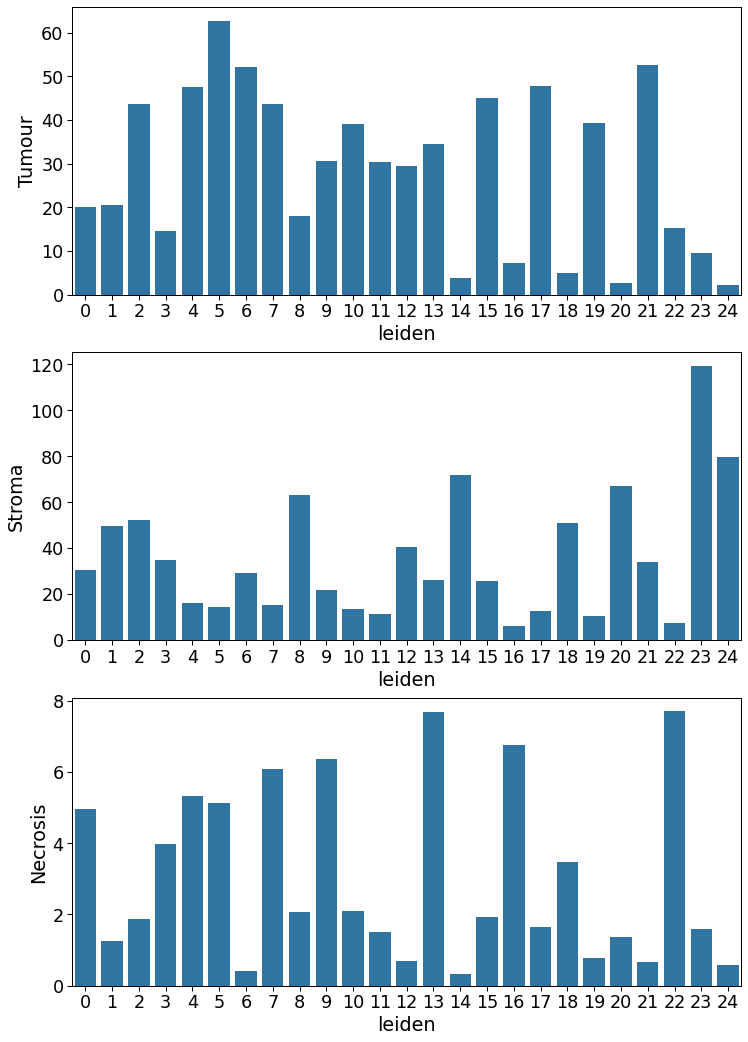

In [15]:
sns.set_context("paper", font_scale=2.0)
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(12,18))
axs = axs.flatten()
sns.barplot(cluster_cell_frequencies, x = 'leiden', y = 'Tumour', errorbar=None, ax=axs[0])
sns.barplot(cluster_cell_frequencies, x = 'leiden', y = 'Stroma', errorbar=None, ax=axs[1])
sns.barplot(cluster_cell_frequencies, x = 'leiden', y = 'Necrosis', errorbar=None, ax=axs[2])

<Axes: xlabel='leiden', ylabel='count'>

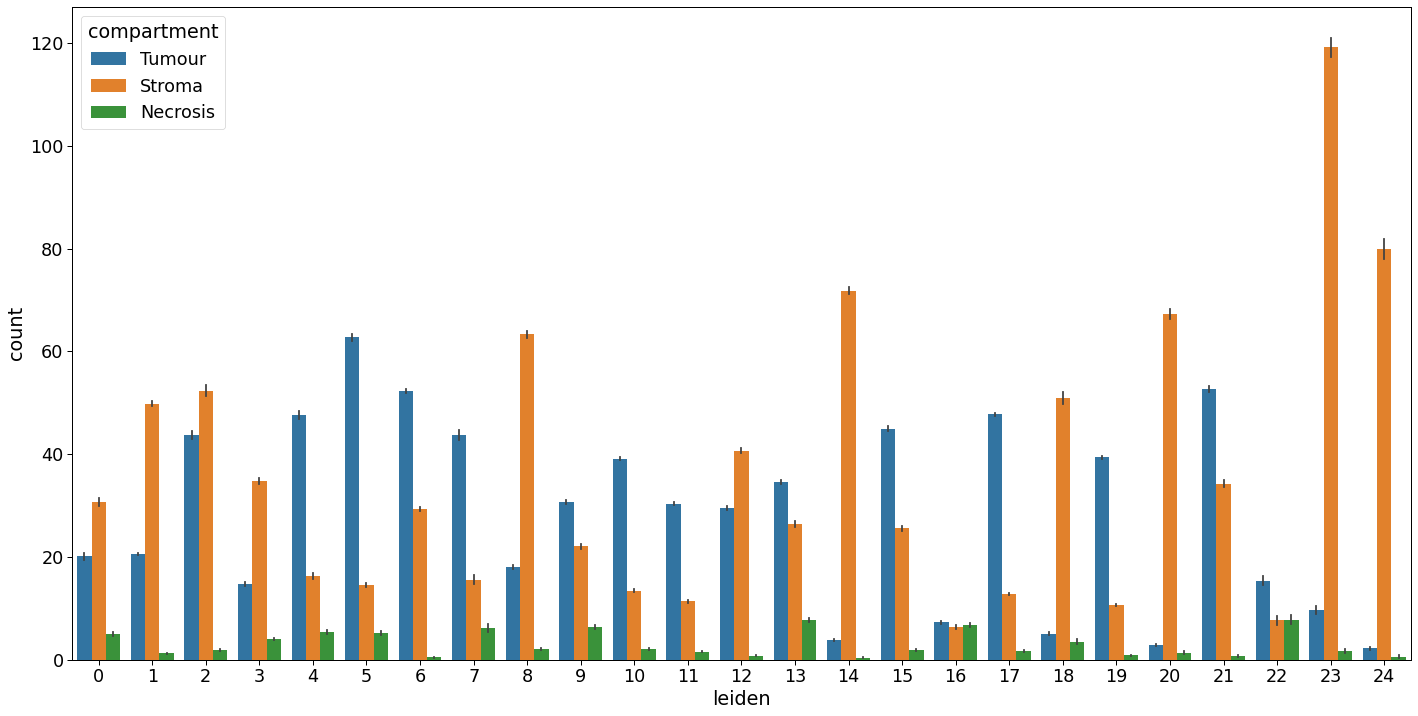

In [16]:
frequencies_melt = pd.melt(cluster_cell_frequencies, id_vars=['core', 'tile', 'leiden'], value_name='count', value_vars=['Tumour', 'Stroma', 'Necrosis'], var_name='compartment')

fig, ax = plt.subplots(figsize=(24,12))
sns.barplot(frequencies_melt, x = 'leiden', y = 'count', hue = 'compartment', errorbar='ci', ax=ax)

In [17]:
adata.obs['Region'].value_counts()

Stroma      5751670
Tumour      5504351
Necrosis     446424
Name: Region, dtype: int64

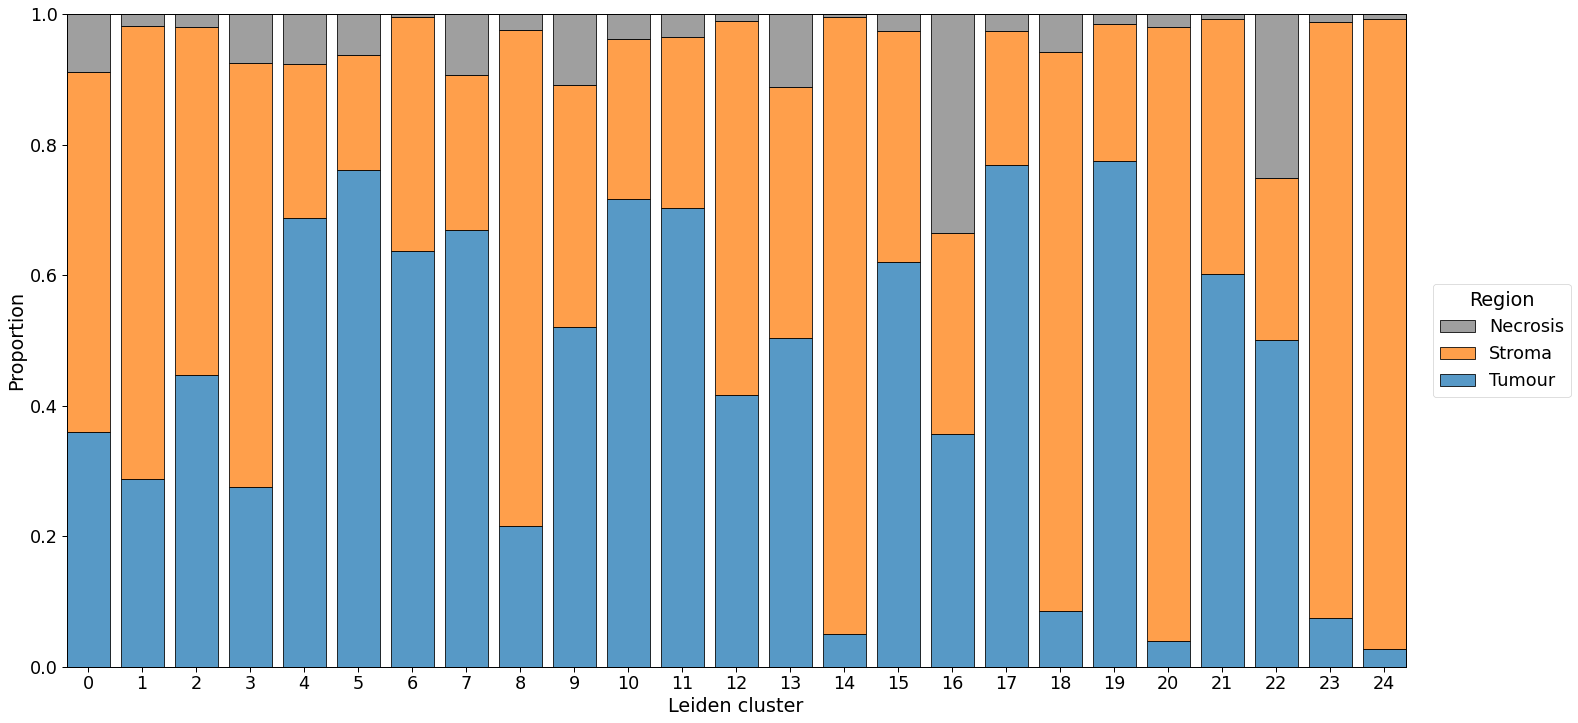

In [18]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(24,12))

sns.histplot(adata.obs, x='leiden', hue='Region', stat='proportion', discrete=True, multiple='fill', 
             palette={'Tumour':sns.color_palette('tab10')[0], 'Stroma':sns.color_palette('tab10')[1], 'Necrosis':sns.color_palette('tab10')[7]},
             shrink=.8,   ax=ax)

ax.set_ylabel('Proportion')
ax.set_xlabel('Leiden cluster')
sns.move_legend(ax, loc='right', bbox_to_anchor=(1.13, 0.5))

Text(0.5, 0, 'Leiden cluster')

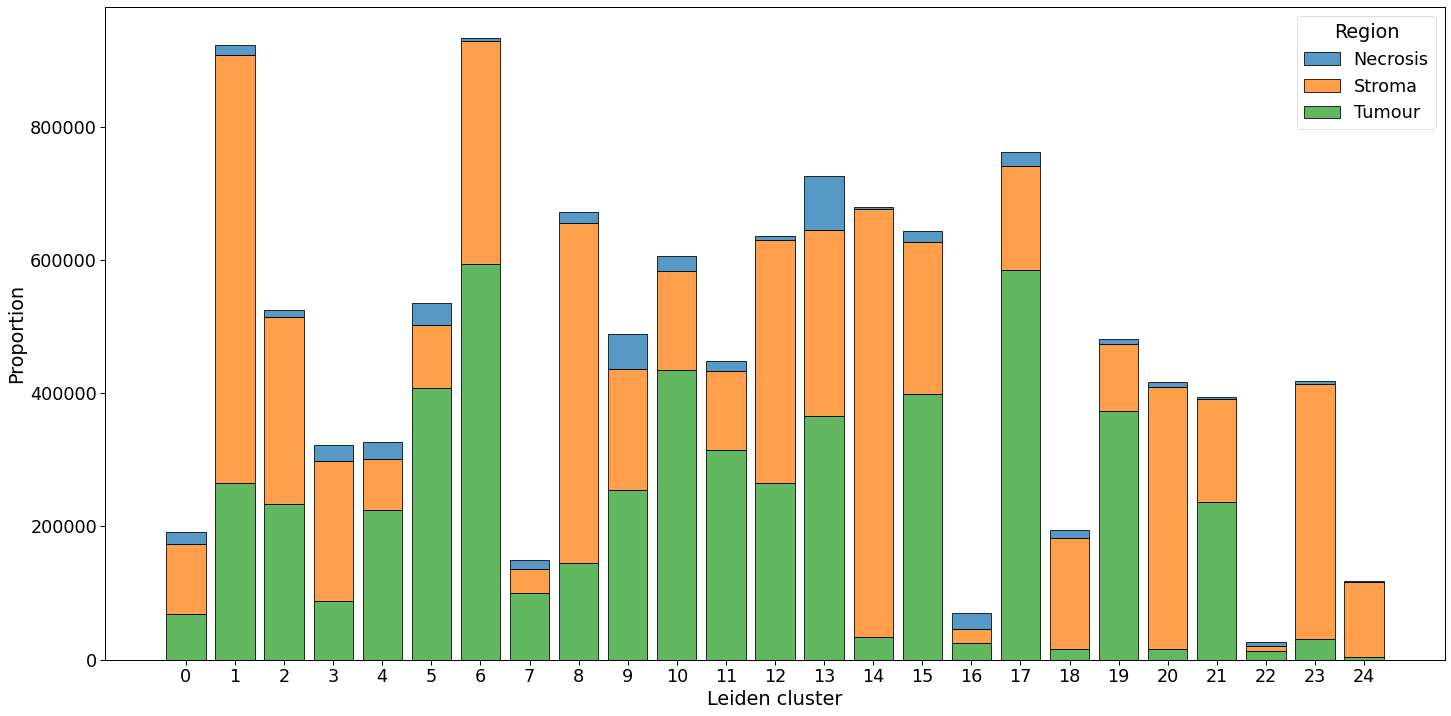

In [19]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(24,12))

sns.histplot(adata.obs, x='leiden', hue='Region', discrete=True, multiple='stack', shrink=.8, ax=ax)
# ax.get_legend().set_visible(False)

ax.set_ylabel('Proportion')
ax.set_xlabel('Leiden cluster')
# ax.set_title('Cluster frequency across TMAs')

In [20]:
cluster_cell_frequencies

,index,Stroma,Tumour,Necrosis,core,tile,leiden,total_cells,prop_tumour,prop_stroma,prop_necrosis
0,Region,52,2,0,01-02-B,111.3728_222.7456_779.6096_890.9824,0,54,0.037037,0.962963,0.0
1,Region,14,5,0,01-02-B,111.3728_222.7456_890.9824_1002.3552,0,19,0.263158,0.736842,0.0
2,Region,27,13,0,01-02-B,222.7456_334.1184_445.4912_556.864,0,40,0.325000,0.675000,0.0
3,Region,19,27,0,01-02-B,222.7456_334.1184_668.2368_779.6096,0,46,0.586957,0.413043,0.0
4,Region,33,18,0,01-02-B,222.7456_334.1184_779.6096_890.9824,0,51,0.352941,0.647059,0.0
...,...,...,...,...,...,...,...,...,...,...,...
172335,Region,87,0,0,23-13-F,779.6096_890.9824_334.1184_445.4912,24,87,0.000000,1.000000,0.0
172336,Region,86,0,0,23-13-F,779.6096_890.9824_445.4912_556.864,24,86,0.000000,1.000000,0.0
172337,Region,79,11,0,23-13-F,779.6096_890.9824_668.2368_779.6096,24,90,0.122222,0.877778,0.0
172338,Region,77,1,0,23-14-I,222.7456_334.1184_222.7456_334.1184,24,78,0.012821,0.987179,0.0


### Mean cell expression

In [21]:
if os.path.isfile(os.path.join(main_path, 'data/results/hallmarks_mean_intensities_tumour.csv')):
    tumour_cluster_mean_intensities = pd.read_csv(os.path.join(main_path, 'data/results/hallmarks_mean_intensities_tumour.csv'))
    stroma_cluster_mean_intensities = pd.read_csv(os.path.join(main_path, 'data/results/hallmarks_mean_intensities_stroma.csv'))
else:

    cell_intensity_list = list()

    for cluster in adata.obs['leiden'].unique():
        for compartment in ['Tumour', 'Stroma']:
            for marker in np.unique(adata.var_names):
                mean_intensity = np.mean(adata.X[(adata.obs['leiden'] == cluster) & (adata.obs['Region'] == compartment), adata.var_names == marker])
                median_intensity = np.median(adata.X[(adata.obs['leiden'] == cluster) & (adata.obs['Region'] == compartment), adata.var_names == marker])
                cell_intensity_list.append([cluster, compartment, marker, mean_intensity, median_intensity])
    
    cell_intensity_df = pd.DataFrame(cell_intensity_list, columns=['leiden', 'compartment', 'marker', 'mean', 'median'])
    cell_intensity_df = cell_intensity_df.replace({'CKPAN':'panCK'})

    tumour_cluster_mean_intensities = cell_intensity_df[cell_intensity_df['compartment'] == 'Tumour'].groupby(['leiden', 'marker']).mean().reset_index().pivot_table(values=['mean'], index='leiden', columns='marker')
    tumour_cluster_mean_intensities.columns = [col[1] for col in tumour_cluster_mean_intensities.columns]

    stroma_cluster_mean_intensities = cell_intensity_df[cell_intensity_df['compartment'] == 'Stroma'].groupby(['leiden', 'marker']).mean().reset_index().pivot_table(values=['mean'], index='leiden', columns='marker')
    stroma_cluster_mean_intensities.columns = [col[1] for col in stroma_cluster_mean_intensities.columns]



In [29]:
tumour_cluster_mean_intensities

,leiden,CA9,CC3,CKPAN,GLB1,Ki67,NCAD,PDL1,VWF
0,0,0.989303,0.110676,2.820390,2.137579,0.822897,0.168708,10.834206,0.425745
1,1,0.204915,0.136451,5.979280,1.626043,0.855848,0.137740,7.976644,0.564866
2,10,1.422915,0.142008,4.787263,1.661546,0.771353,0.152402,12.404713,0.479037
3,11,0.229709,0.131036,5.723745,2.098861,0.590070,0.126266,8.387126,0.612555
4,12,0.256035,0.144965,6.050154,2.404943,0.621915,0.195343,8.862491,0.644928
5,13,0.207700,0.100337,5.239629,0.446754,0.526901,0.043686,5.621280,0.345140
6,14,0.218202,0.131452,5.083782,1.965874,0.656114,0.301177,7.945456,0.816660
7,15,1.335599,0.144212,4.541195,2.243619,1.016268,0.190146,13.493848,0.542992
8,16,0.285888,0.136021,5.075938,2.035379,0.523548,0.176465,8.486006,0.570583
9,17,0.169958,0.115599,4.898905,1.877206,0.948059,0.102455,8.289531,0.545655


In [23]:
stroma_cluster_mean_intensities

,leiden,CA9,CC3,CKPAN,GLB1,Ki67,NCAD,PDL1,VWF
0,0,0.739689,0.050704,0.177549,1.036063,0.281525,0.109255,7.893558,0.377841
1,1,0.055662,0.026700,0.208350,1.389131,0.362500,0.102396,6.963261,0.591188
2,10,0.315510,0.041839,0.369421,1.204216,0.307644,0.106859,6.918306,0.569179
3,11,0.067364,0.030793,0.379446,1.217452,0.296063,0.083760,6.443295,0.727219
4,12,0.068029,0.036953,0.310442,1.285905,0.297780,0.097305,6.352962,0.859034
5,13,0.058202,0.020822,0.326843,0.429988,0.243877,0.039263,4.325506,0.508241
6,14,0.047070,0.027968,0.116775,1.128168,0.278550,0.101176,6.240704,0.965044
7,15,0.237097,0.042386,0.288706,1.711895,0.412913,0.141417,8.407272,0.622215
8,16,0.071159,0.030248,0.286619,1.156534,0.309254,0.107172,6.713032,0.650050
9,17,0.090427,0.038150,0.392963,1.892214,0.436034,0.126059,8.147331,0.697704


In [33]:
cluster_mean_inteisities = tumour_cluster_mean_intensities.copy(deep=True)
cluster_mean_inteisities['VWF'] = stroma_cluster_mean_intensities['VWF']

cluster_mean_inteisities = cluster_mean_inteisities.drop(labels='CKPAN', axis=1)
cluster_mean_inteisities = cluster_mean_inteisities.set_index('leiden')
cluster_mean_inteisities = cluster_mean_inteisities.T
cluster_mean_inteisities

leiden,0,1,10,11,12,13,14,15,16,17,...,22,23,24,3,4,5,6,7,8,9
CA9,0.989303,0.204915,1.422915,0.229709,0.256035,0.207700,0.218202,1.335599,0.285888,0.169958,...,0.466889,0.127113,0.134836,0.201817,0.262092,0.185337,0.269082,0.132138,0.201460,0.105039
CC3,0.110676,0.136451,0.142008,0.131036,0.144965,0.100337,0.131452,0.144212,0.136021,0.115599,...,0.150037,0.113431,0.087849,0.130361,0.143459,0.089267,0.115141,0.073869,0.116458,0.083791
GLB1,2.137579,1.626043,1.661546,2.098861,2.404943,0.446754,1.965874,2.243619,2.035379,1.877206,...,3.041280,1.589678,0.601269,2.564330,2.582180,1.497942,3.270993,2.506423,2.475955,1.327729
Ki67,0.822897,0.855848,0.771353,0.590070,0.621915,0.526901,0.656114,1.016268,0.523548,0.948059,...,0.890239,0.953834,0.269709,0.754087,1.209546,0.789274,0.557654,0.901911,1.112249,0.352129
NCAD,0.168708,0.137740,0.152402,0.126266,0.195343,0.043686,0.301177,0.190146,0.176465,0.102455,...,0.372258,0.139448,0.080545,0.205564,3.484219,0.103308,0.142858,0.157991,0.284205,0.076320
PDL1,10.834206,7.976644,12.404713,8.387126,8.862491,5.621280,7.945456,13.493848,8.486006,8.289531,...,12.886910,10.572030,5.028146,9.567585,9.136761,7.843085,10.406189,9.302275,10.500335,6.862482
VWF,0.377841,0.591188,0.569179,0.727219,0.859034,0.508241,0.965044,0.622215,0.650050,0.697704,...,0.759545,0.439362,0.778859,0.673660,0.652056,0.599425,0.846721,0.725594,0.674517,0.873707


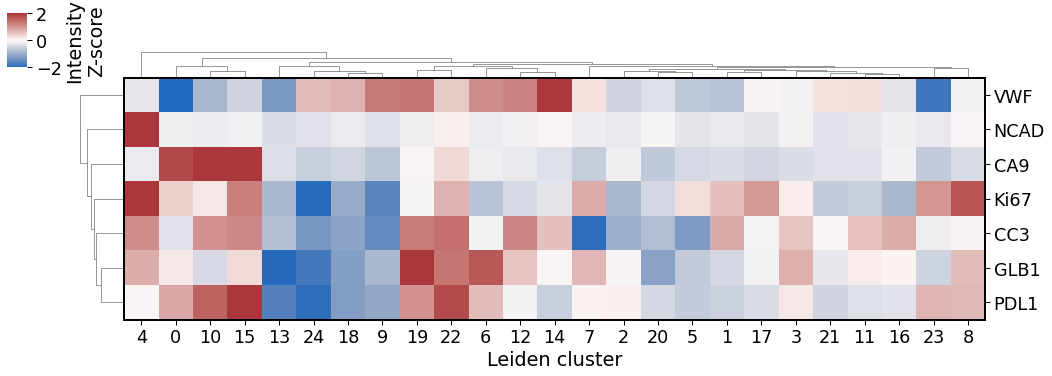

In [34]:
from matplotlib.patches import Rectangle

g = sns.clustermap(cluster_mean_inteisities,
               z_score=0,
               vmin=-2,
               vmax=2,
               cmap='vlag',
               linewidths=.0,
               edgecolors='black',
               dendrogram_ratio=(.05, .1),
               cbar_kws={'label':'Intensity\nZ-score'},
               cbar_pos=(-0.05, .895, .02, .15),
               figsize=(14,5))

g.ax_heatmap.collections[0].set_edgecolor('black')
g.ax_heatmap.collections[0].set_linewidth(.0)

n_rows, n_cols = cluster_mean_inteisities.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_xlabel('Leiden cluster')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0);

plt.show()

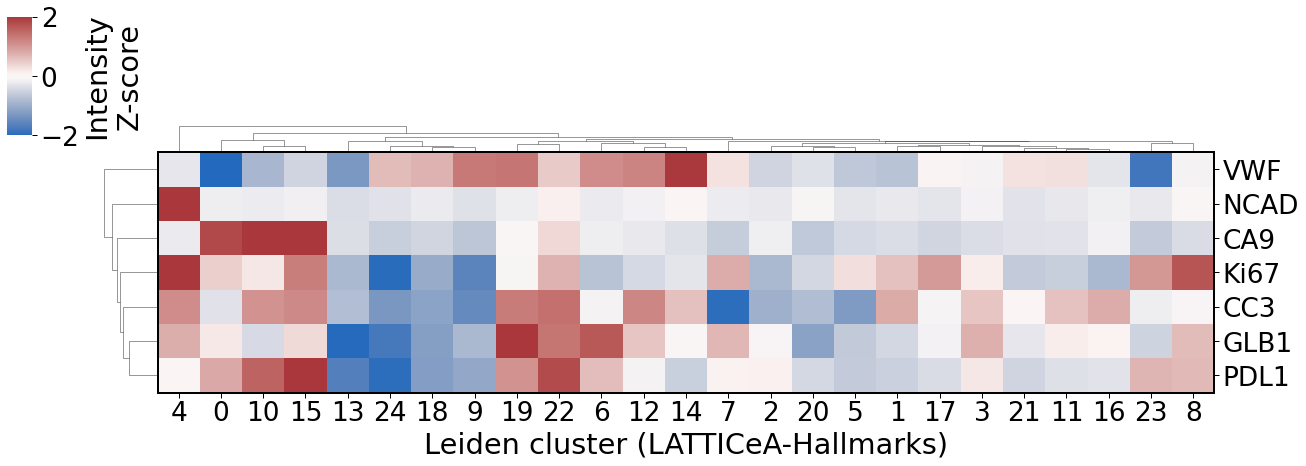

In [ ]:
# cluster_mean_inteisities_t = cluster_mean_inteisities.T
sns.set_context("paper", font_scale=3.0)

g = sns.clustermap(cluster_mean_inteisities,
               z_score=0,
               vmin=-2,
               vmax=2,
               cmap='vlag',
               linewidths=.0,
               edgecolors='black',
               dendrogram_ratio=(.05, .1),
               xticklabels=1,
               cbar_kws={'label':'Intensity\nZ-score'},
               cbar_pos=(-0.05, .895, .02, .3),
               figsize=(17.5,5.5))

g.ax_heatmap.collections[0].set_edgecolor('black')
g.ax_heatmap.collections[0].set_linewidth(.0)

n_rows, n_cols = cluster_mean_inteisities.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_xlabel('Leiden cluster (LATTICeA-Hallmarks)')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0);

plt.show()